In [ ]:
# Project dependencies and imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#  datetime  Package
from datetime import datetime

#  Serialization Package
import joblib

In [3]:
data = joblib.load("../data/processed/cleaned_data.pkl")

In [4]:
groupby_invoice = data.groupby(['Invoice','InvoiceDate', 'Customer ID'])['Total_Price'].sum()
groupby_invoice = groupby_invoice.sort_values(ascending=False).reset_index()
groupby_invoice.head()

,Invoice,InvoiceDate,Customer ID,Total_Price
0,493819,2010-01-07 12:34:00,14156,44051.60
1,524181,2010-09-27 16:59:00,17450,33167.80
2,526934,2010-10-14 09:46:00,18102,26007.08
3,515944,2010-07-15 15:29:00,18102,22863.36
4,517731,2010-08-01 13:31:00,18102,21984.00


## Modelling

In [5]:
groupby_invoice = groupby_invoice.sort_values(['Customer ID', 'InvoiceDate'])

groupby_invoice['IPT'] = groupby_invoice.groupby('Customer ID')['InvoiceDate'].diff().dt.days

In [6]:
groupby_invoice.head()

,Invoice,InvoiceDate,Customer ID,Total_Price,IPT
17989,491725,2009-12-14 08:34:00,12346,45.0,NaN
18532,491742,2009-12-14 11:00:00,12346,22.5,0.0
18533,491744,2009-12-14 11:02:00,12346,22.5,0.0
18525,492718,2009-12-18 10:47:00,12346,22.5,3.0
19236,492722,2009-12-18 10:55:00,12346,1.0,0.0


In [7]:
cust_ipt = groupby_invoice.groupby('Customer ID')['IPT'].median()
# median IPT overall
median_ipt = cust_ipt.median()

In [8]:
median_ipt

44.0

- The median interpurchase time is 44 days = 6 weeks 
- Using this as a reference, define a 12 weeks Observation Window and a 6 week Performance Window for the churn analysis.
- This means that the 12 week window will be used to predict whether the customer will churn in the following 6 week period.


In [9]:
groupby_invoice.head()

,Invoice,InvoiceDate,Customer ID,Total_Price,IPT
17989,491725,2009-12-14 08:34:00,12346,45.0,NaN
18532,491742,2009-12-14 11:00:00,12346,22.5,0.0
18533,491744,2009-12-14 11:02:00,12346,22.5,0.0
18525,492718,2009-12-18 10:47:00,12346,22.5,3.0
19236,492722,2009-12-18 10:55:00,12346,1.0,0.0


In [10]:
groupby_invoice.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19250 entries, 17989 to 6634
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Invoice      19250 non-null  object        
 1   InvoiceDate  19250 non-null  datetime64[ns]
 2   Customer ID  19250 non-null  object        
 3   Total_Price  19250 non-null  float64       
 4   IPT          14936 non-null  float64       
dtypes: datetime64[ns](1), float64(2), object(2)
memory usage: 902.3+ KB


In [11]:
groupby_invoice['Week'] = groupby_invoice['InvoiceDate'].dt.isocalendar().week
groupby_invoice['Year'] = groupby_invoice['InvoiceDate'].dt.year

In [12]:
groupby_invoice.head()

,Invoice,InvoiceDate,Customer ID,Total_Price,IPT,Week,Year
17989,491725,2009-12-14 08:34:00,12346,45.0,NaN,51,2009
18532,491742,2009-12-14 11:00:00,12346,22.5,0.0,51,2009
18533,491744,2009-12-14 11:02:00,12346,22.5,0.0,51,2009
18525,492718,2009-12-18 10:47:00,12346,22.5,3.0,51,2009
19236,492722,2009-12-18 10:55:00,12346,1.0,0.0,51,2009


In [13]:
groupby_invoice = groupby_invoice.sort_values(['InvoiceDate', 'Week'])
groupby_invoice.head()

,Invoice,InvoiceDate,Customer ID,Total_Price,IPT,Week,Year
4485,489434,2009-12-01 07:45:00,13085,505.30,NaN,49,2009
14907,489435,2009-12-01 07:46:00,13085,145.80,0.0,49,2009
3153,489436,2009-12-01 09:06:00,13078,630.33,NaN,49,2009
9031,489437,2009-12-01 09:08:00,15362,310.75,NaN,49,2009
365,489438,2009-12-01 09:24:00,18102,2286.24,NaN,49,2009


- Our Data is starting from  1 Desember 2012 (week 49)  and we need that week to be the first week.

In [14]:
groupby_invoice['WeekIndex'] = (groupby_invoice['Year'] - groupby_invoice['Year'].min()) * 52 + groupby_invoice['Week'] - 48

display(groupby_invoice.head())

# Check the number of week availabel in the data
print("Number of weeks in the Data:", groupby_invoice['WeekIndex'].max())

,Invoice,InvoiceDate,Customer ID,Total_Price,IPT,Week,Year,WeekIndex
4485,489434,2009-12-01 07:45:00,13085,505.30,NaN,49,2009,1
14907,489435,2009-12-01 07:46:00,13085,145.80,0.0,49,2009,1
3153,489436,2009-12-01 09:06:00,13078,630.33,NaN,49,2009,1
9031,489437,2009-12-01 09:08:00,15362,310.75,NaN,49,2009,1
365,489438,2009-12-01 09:24:00,18102,2286.24,NaN,49,2009,1


Number of weeks in the Data: 53


In [15]:
unique_customers = groupby_invoice['Customer ID'].unique()

# Create weeklylog dataframe consist of zeros
weekly_log = pd.DataFrame(0, index = unique_customers, columns = np.arange(1,54))

weekly_log.head()

,1,2,3,4,5,6,7,8,9,10,...,44,45,46,47,48,49,50,51,52,53
13085,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
13078,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
15362,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
18102,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12682,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [16]:
# Fill the data
for cust, group in groupby_invoice.groupby('Customer ID'):
    weeks = group['WeekIndex'].unique()
    weekly_log.loc[cust, weeks] = 1

#Validation
weekly_log.head()

,1,2,3,4,5,6,7,8,9,10,...,44,45,46,47,48,49,50,51,52,53
13085,1,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
13078,1,1,1,0,1,0,1,0,1,0,...,0,1,0,1,0,1,1,1,1,1
15362,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
18102,1,1,1,1,1,1,0,0,1,0,...,0,1,0,0,0,1,1,0,0,1
12682,1,1,0,1,0,1,0,0,1,1,...,0,1,0,0,0,1,1,0,1,1


In [17]:
weekly_log.shape

(4314, 53)

In [18]:
def create_weekly_spending_log(df):
    df = df.copy()
    df["WeekIndex"] = df["InvoiceDate"].dt.isocalendar().week

    # pivot -> customers as rows, week as columns, values = total spending
    spending_log = df.pivot_table(
        index="Customer ID",
        columns="Week",
        values="Total_Price",
        aggfunc="sum",
        fill_value=0
    )
    return spending_log

In [19]:
spending_log = create_weekly_spending_log(groupby_invoice)
spending_log.head()

Week,1,2,3,4,5,6,7,8,9,10,...,43,44,45,46,47,48,49,50,51,52
Customer ID,,,,,,,,,,,,,,,,,,,,,
12346,45.0,22.5,22.5,0.0,0.0,0.0,0.0,0.0,27.05,0.0,...,0.00,0.0,0.0,0.0,0.0,0.00,0.00,0.0,113.5,0.0
12347,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,...,611.53,0.0,0.0,0.0,0.0,0.00,711.79,0.0,0.0,0.0
12348,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,...,0.00,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0
12349,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,...,1402.62,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0
12351,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,...,0.00,0.0,0.0,0.0,0.0,300.93,0.00,0.0,0.0,0.0


In [20]:
def recency(row):
    """
    Weeks since last purchase inside the window.
    If no purchase: return len(row)
    """
    if row.sum() == 0:
        return len(row)
    last_week_idx = row.to_numpy().nonzero()[0].max()
    return len(row) - 1 - last_week_idx


def frequency(subset):
    """Total purchases in the window."""
    return subset.sum(axis=1)


def tenure(first_purchase_week, ow_end_week):
    """Customer age (in weeks) at the end of the window."""
    return ow_end_week - first_purchase_week + 1


def churn_label(log, pw_start, pw_end):
    """
    Label churn = 1 if no transaction in PW,
    otherwise 0.
    """
    pw_subset = log.iloc[:, pw_start:pw_end+1]
    churn = (pw_subset.sum(axis=1) == 0).astype(int)
    return churn

def compute_window(log, spending_log, ow_start, ow_end, pw_start, pw_end, first_purchase_week=None):
    """
    Compute RFM + Monetary + AOV + Tenure + Churn for one window (with gap already handled).
    """
    # Observation window subset
    log_ow = log.iloc[:, ow_start:ow_end + 1]
    spending_ow = spending_log.iloc[:, ow_start:ow_end + 1]

    # Frequency & Recency
    freq = frequency(log_ow)
    rec = log_ow.apply(recency, axis=1)

    # Monetary & AOV
    monetary_val = spending_ow.sum(axis=1)
    aov = monetary_val / freq.replace(0, np.nan)
    aov = aov.fillna(0)

    # Tenure
    if first_purchase_week is not None:
        tenure_val = tenure(first_purchase_week, ow_end)
    else:
        tenure_val = pd.Series([0] * len(log), index=log.index)

    # Churn label from prediction window
    churn = churn_label(log, pw_start, pw_end)

    # Build final dataframe
    rfm_df = pd.DataFrame({
        'Customer': log.index,
        'Window_End': ow_end,
        'OW_Start': ow_start,
        'OW_End': ow_end,
        'PW_Start': pw_start,
        'PW_End': pw_end,
        'Recency': rec.values,
        'Frequency': freq.values,
        'Monetary': monetary_val.values,
        'AOV': aov.values,
        'Tenure': tenure_val.values,
        'Churn': churn.values,
    })

    return rfm_df

def sliding_rfm_churn(log, spending_log, ow_weeks=12, pw_weeks=6, gap_weeks=1, first_purchase_week=None):
    """
    Generate RFM dataset with sliding windows + GAP to prevent data leakage.
    
    Parameters:
    - ow_weeks: length of observation window (e.g., 12 weeks)
    - pw_weeks: length of prediction window (e.g., 6 weeks)
    - gap_weeks: buffer weeks between OW and PW (e.g., 1) → CRUCIAL for no leakage
    - first_purchase_week: optional Series (index=customer, value=first week of purchase)
    
    Example:
        OW: week 10–21 (12 weeks)
        Gap: week 22
        PW: week 23–28 (6 weeks) → label based on activity here
    """
    total_weeks = log.shape[1]
    records = []

    # Last possible OW end: must leave space for gap + full prediction window
    max_ow_end = total_weeks - gap_weeks - pw_weeks

    for ow_end in range(ow_weeks - 1, max_ow_end + 1):
        ow_start = ow_end - ow_weeks + 1
        pw_start = ow_end + gap_weeks
        pw_end = pw_start + pw_weeks - 1

        # Safety check (should not happen if max_ow_end correct)
        if pw_end >= total_weeks:
            continue

        window_df = compute_window(
            log=log,
            spending_log=spending_log,
            ow_start=ow_start,
            ow_end=ow_end,
            pw_start=pw_start,
            pw_end=pw_end,
            first_purchase_week=first_purchase_week
        )
        records.append(window_df)

    if not records:
        raise ValueError("No valid windows generated. Check data length and parameters.")

    return pd.concat(records, ignore_index=True)

In [24]:
rfm_churn_all = sliding_rfm_churn(weekly_log, spending_log, ow_weeks=12, pw_weeks=6)

rfm_churn_all.head()


,Customer,Window_End,OW_Start,OW_End,PW_Start,PW_End,Recency,Frequency,Monetary,AOV,Tenure,Churn
0,13085,11,0,11,12,17,4,2,117.05,29.2625,0,1
1,13078,11,0,11,12,17,1,7,0.00,0.0000,0,0
2,15362,11,0,11,12,17,11,1,0.00,0.0000,0,1
3,18102,11,0,11,12,17,0,9,0.00,0.0000,0,0
4,12682,11,0,11,12,17,0,7,0.00,0.0000,0,0


In [25]:
rfm_churn_all['Churn'].value_counts(normalize=True)

Churn
1    0.675688
0    0.324312
Name: proportion, dtype: float64

- We don't need to use resampling techniques because the proportions aren't severely imbalanced.
- We need to split the data to test and train set.

In [26]:
rfm_churn_test = rfm_churn_all[rfm_churn_all['Window_End']> 35]
rfm_churn_train = rfm_churn_all[~(rfm_churn_all['Window_End']> 35)]

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve

X_train = rfm_churn_train[['Frequency','Recency','Monetary','Tenure']]  # fitur
y_train = rfm_churn_train['Churn']                           # target

model = LogisticRegression()
model.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [28]:
def eval_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc_score = roc_auc_score(y_true, y_prob)
    cm = confusion_matrix(y_true, y_pred)
        
    print("Accuracy      :", acc)
    print("Precision     :", prec)
    print("Recall        :", rec)
    print("F1-score      :", f1)
    print("ROC-AUC       :", auc_score)
    
    # --- Confusion Matrix ---
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.gca().set_xticklabels(["Not Churn (0)", "Churn (1)"])
    plt.gca().set_yticklabels(["Not Churn (0)", "Churn (1)"])
    plt.show()

Accuracy      : 0.7492350486787205
Precision     : 0.7501373530322555
Recall        : 0.9736535020615616
F1-score      : 0.8474042644428521
ROC-AUC       : 0.6650614320387536


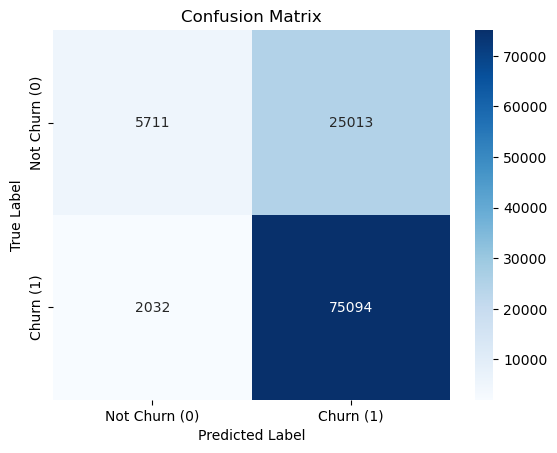

In [29]:
y_pred = model.predict(X_train)          
y_prob = model.predict_proba(X_train)[:,1]  

eval_metrics(y_train, y_pred, y_prob)

In [30]:
def optimal_threshold(y_true, y_prob, show_plot=True):
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    
    #  ROC Curve
    fpr, tpr, roc_thresh = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    
    #  Precision-Recall Curve + Max F1
    precision, recall, pr_thresh = precision_recall_curve(y_true, y_prob)
    f1_scores = 2 * recall * precision / (recall + precision + 1e-12)
    best_f1_idx = np.argmax(f1_scores)
    thresh_f1 = pr_thresh[best_f1_idx]
    best_f1 = f1_scores[best_f1_idx]
    

    #  Closest to top-left corner (0,1) 
    distance = np.sqrt(fpr**2 + (1 - tpr)**2)
    best_corner_idx = np.argmin(distance)
    thresh_corner = roc_thresh[best_corner_idx]
    dist_min = distance[best_corner_idx]

    # Print all the result
    print(f"ROC AUC Score: {auc}")

    print(f"Best Threshold (Max F1) {thresh_f1}")
    print(f"Best Threshold (Closest to (0,1)): {thresh_corner}")

    # Plotting
    fig, ax = plt.subplots(1, 1, figsize=(9, 7))

    ax.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.4f})', linewidth=2, color='darkorange')
    ax.plot([0, 1], [0, 1], '--', color='gray', label='Random Classifier')


    # Closest to (0,1) 
    ax.scatter(fpr[best_corner_idx], tpr[best_corner_idx], 
               color='red', s=180, zorder=5, marker='X', edgecolors='black', linewidth=2,
               label=f'Closest to (0,1)\nThresh = {thresh_corner:.4f}')

    # Max F1 point 
    idx_f1_roc = np.argmin(np.abs(roc_thresh - thresh_f1))
    ax.scatter(fpr[idx_f1_roc], tpr[idx_f1_roc], 
               color='blue', s=120, zorder=5, marker='D',
               label=f'Max F1 (PR)\nThresh ≈ {thresh_f1:.4f}')


    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curve', fontsize=14, pad=20)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)

    plt.tight_layout()
    plt.show()

    return thresh_f1, thresh_corner


ROC AUC Score: 0.6650614320387536
Best Threshold (Max F1) 0.35834032378677777
Best Threshold (Closest to (0,1)): 0.7290878242072304


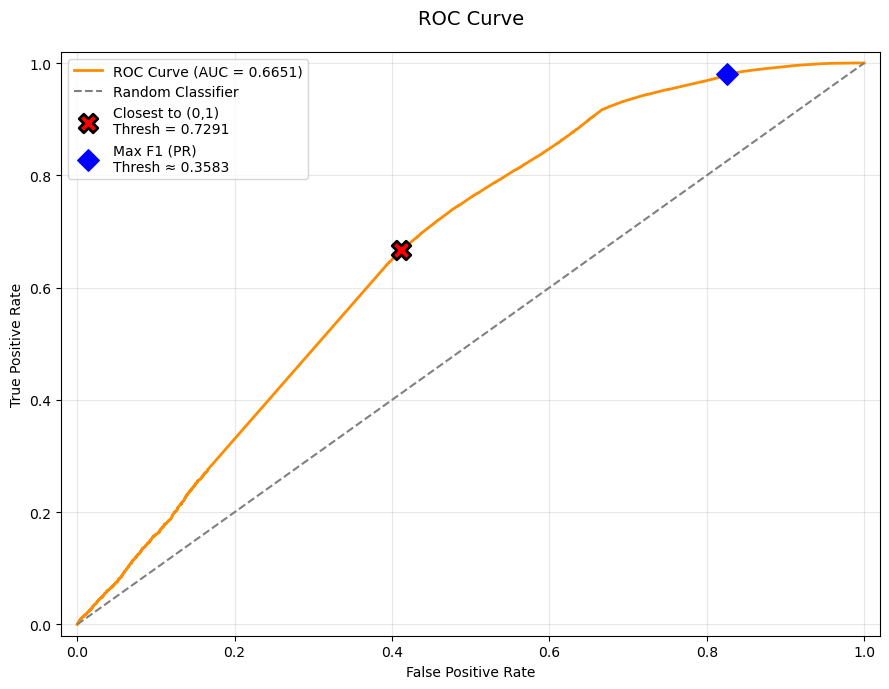

In [31]:
thresh_f1, thresh_corner = optimal_threshold(y_train, y_prob)

- Let's see how each threshold perform on the training data

Accuracy      : 0.750477515067223
Precision     : 0.7486999158040711
Recall        : 0.9800197080102689
F1-score      : 0.8488833732964213
ROC-AUC       : 0.6650614320387536


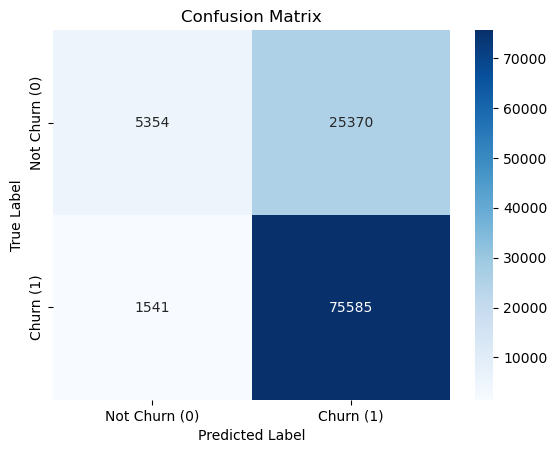

In [32]:
y_pred_f1 = (y_prob >= thresh_f1).astype(int)

eval_metrics(y_train, y_pred_f1, y_prob)

Accuracy      : 0.6441910060268892
Precision     : 0.8025892494612237
Recall        : 0.666351165625081
F1-score      : 0.7281524511192973
ROC-AUC       : 0.6650614320387536


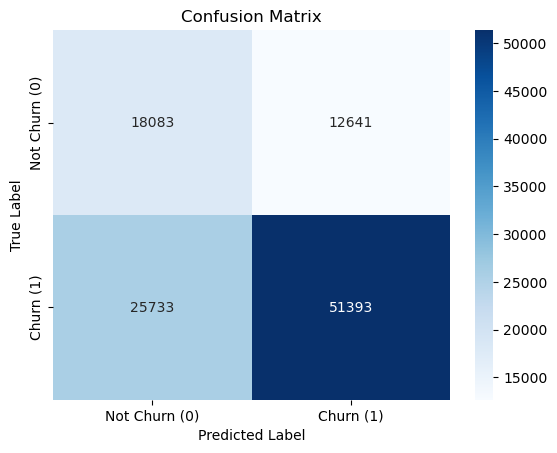

In [33]:
y_pred_corner = (y_prob >= thresh_corner).astype(int)

eval_metrics(y_train, y_pred_corner, y_prob)

- The threshold obtained by maximizing F1 yields a noticeably higher recall compared to the threshold from the closest-to-(0,1) method.
- Given that catching churned customers is more important than keeping the prediction list perfectly clean (precision), we should go with the Max F1 threshold

Accuracy      : 0.6257849707084756
Precision     : 0.6140908368704179
Recall        : 0.9728165114523031
F1-score      : 0.7529081093115155
ROC-AUC       : 0.5876311966524141


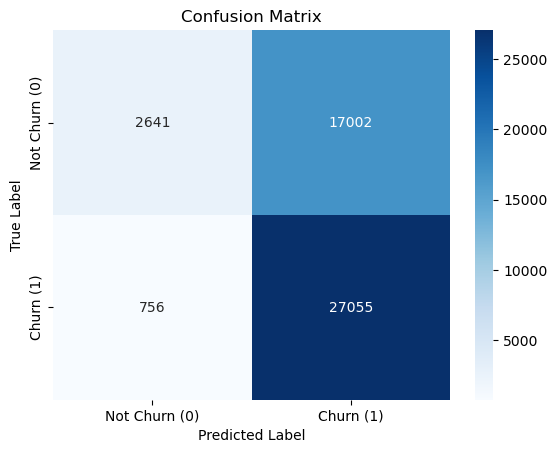

In [34]:
# Testing it on the test set
best_threshold = thresh_f1
X_test = rfm_churn_test[['Frequency','Recency','Monetary','Tenure']]
y_test = rfm_churn_test['Churn'] 
        
y_prob_test = model.predict_proba(X_test)[:,1] 
y_pred_test = (y_prob_test >= best_threshold).astype(int)

eval_metrics(y_test, y_pred_test, y_prob_test)
